In [1]:
#SID: 2305603
#Week 8
#Naive Bayes Classifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


Rows Columns
(887, 8)
   Passenger Class  Female  Male   Age  Siblings/Spouses Aboard  \
0                3       0     1  22.0                        1   
1                1       1     0  38.0                        1   
2                3       1     0  26.0                        0   
3                1       1     0  35.0                        1   
4                3       0     1  35.0                        0   

   Parents/Children Aboard     Fare  Survived  
0                        0   7.2500         0  
1                        0  71.2833         1  
2                        0   7.9250         1  
3                        0  53.1000         1  
4                        0   8.0500         0  

 Survived
0    545
1    342
Name: count, dtype: int64


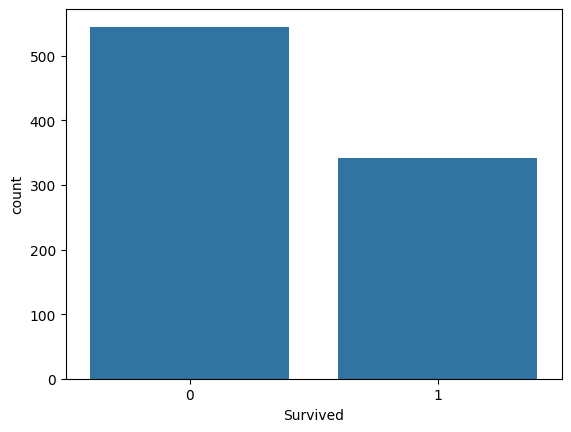

In [ ]:
#Read and Display Data Set

#First, read in CSV and assign it to a variable called "data"
data = pd.read_csv("data/poisonous_or_edible_mushrooms.csvtitanic.csv")
#data = pd.read_csv("data/titanic.csv")

#Second, display maximum rows and columns
print('\nRows Columns') #Indicates rows and columns
print(data.shape) #gets the number of rows and columns of data set

pd.set_option('display.max_columns', None) #optional setting to show all feature columns

#Third, display first five rows to check data
print(data.head(5))

#Select last column (assuming the last column is the class)
last_column = data.iloc[:, -1] #using iloc to select the last column

#Count occurences of 0's and 1's
value_counts = last_column.value_counts()

#Print the value counts and check for imbalance
print('\n' , value_counts)

sns.countplot(x="Survived", data=data)
sns.countplot(x="class", data=data)
plt.show()

Axes(0.125,0.11;0.62x0.77)


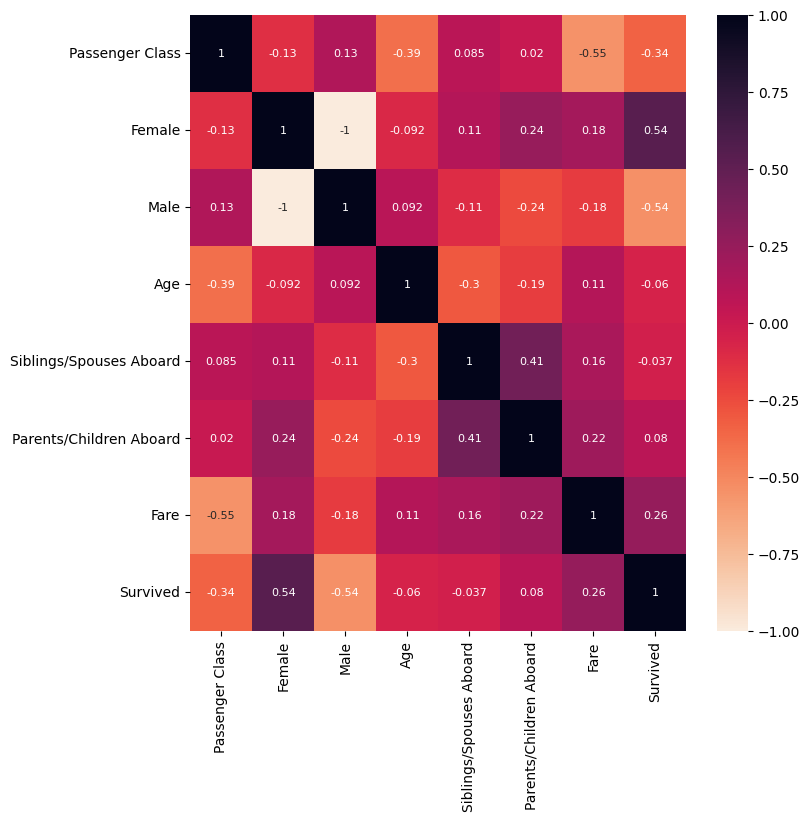

In [8]:
#Display Feature Relations of Data Set
plt.figure(figsize=(8,8)) #Adjust width and height
print(sns.heatmap(data.corr(),annot=True, annot_kws={"size":8}, cmap= sns.cm.rocket_r))

In [9]:
#Declare X and Y Variables and Split the Dataset into Train and Test sections
X=data.drop(['Survived'], axis=1).values #X Variables = all common except the last one

#Declare last column to be the Dependent variable Y
y=data['Survived'].values #Y Variable = last column

#Split Data Set 70% training and 30% Testing. Initial data shuffle to zero
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7,test_size=0.3, random_state=0)

In [10]:
#Define the MODELS
models = {
    "GAUSSIAN": GaussianNB(),
    "MULTINOMIAL": MultinomialNB(),
    "BERNOULLI": BernoulliNB(),
    "CATEGORICAL": CategoricalNB(),
    "COMPLEMENT": ComplementNB()
}

#Loop through the models and evaluate
for name, model in models.items():
    print(f"\n\n***{name}***")
    print(f"-----------------")

    #Train the model
    model.fit(X_train, y_train)

    #Make Predictions
    y_pred = model.predict(X_test)

    #Evaluate
    print('\nConfusion Matrix = \n', confusion_matrix(y_test, y_pred))
    print('\nAccuracy = ', accuracy_score(y_test, y_pred))
    print('\nPrecision = ', precision_score(y_test, y_pred))
    print('\nRecall = ', recall_score(y_test, y_pred))
    print('\nF1 Score = ', f1_score(y_test, y_pred))



***GAUSSIAN***
-----------------

Confusion Matrix = 
 [[134  28]
 [ 32  73]]

Accuracy =  0.7752808988764045

Precision =  0.7227722772277227

Recall =  0.6952380952380952

F1 Score =  0.7087378640776699


***MULTINOMIAL***
-----------------

Confusion Matrix = 
 [[134  28]
 [ 58  47]]

Accuracy =  0.6779026217228464

Precision =  0.6266666666666667

Recall =  0.44761904761904764

F1 Score =  0.5222222222222223


***BERNOULLI***
-----------------

Confusion Matrix = 
 [[135  27]
 [ 34  71]]

Accuracy =  0.7715355805243446

Precision =  0.7244897959183674

Recall =  0.6761904761904762

F1 Score =  0.6995073891625616


***CATEGORICAL***
-----------------

Confusion Matrix = 
 [[134  28]
 [ 31  74]]

Accuracy =  0.7790262172284644

Precision =  0.7254901960784313

Recall =  0.7047619047619048

F1 Score =  0.714975845410628


***COMPLEMENT***
-----------------

Confusion Matrix = 
 [[134  28]
 [ 56  49]]

Accuracy =  0.6853932584269663

Precision =  0.6363636363636364

Recall =  0.46666

In [ ]:
#Optimising Model for better metrics

param_grid = {
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(GaussianNB(),param_grid,verbose=3, cv=3) #'Verbose' = Added information in Grid Search. 1 = Little, 2 = Average, 3 = Full info
grid.fit(X_train, y_train)
grid.best_params_
grid_predictions = grid.predict(X_test)

#Evaluate Model
print('\nConfusion Matrix = \n', confusion_matrix(y_test, y_pred))
print('\nAccuracy = ', accuracy_score(y_test, y_pred))
print('\nPrecision = ', precision_score(y_test, y_pred))
print('\nRecall = ', recall_score(y_test, y_pred))
print('\nF1 Score = ', f1_score(y_test, y_pred))